In [4]:
from parsing_library import *

In [1]:
1+1

2

In [5]:

def calculate_rmse_per_size(data_dir, saved_fits_dir, inference_method, sizes, D):

    rmse_scores = {}

    for data_id in range(1, 11):
        data_path = os.path.join(data_dir, f"{data_id}.json")
        with open(data_path) as f:
            data = json.load(f)
        
        true_theta = np.array(data['theta'])
        vocabulary = data['vocabulary']

        for size in sizes:
            fit = load_fit_by_size(size, os.path.join(saved_fits_dir, str(data_id)))

            if fit is None:
                continue

            if inference_method == 'hmc':
                estimated_word_vectors = fit['word_vectors']
                estimated_context_vectors = fit['context_vectors']
            elif inference_method == 'vi':
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.variational_sample_pd, vocabulary, D=D)
            elif inference_method in ('map', 'laplace'):
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit.optimized_params_pd, vocabulary, D=D)
            elif inference_method == 'gibbs':
                filepath = os.path.join(saved_fits_dir, str(data_id), f'gibbs-samples-N-{size}.csv')
                estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_gibbs(filepath, vocabulary)

            num_samples = estimated_word_vectors.shape[2] if inference_method != 'map' else 1

            # Combine and reshape theta samples
            theta_combined = np.concatenate((estimated_word_vectors, estimated_context_vectors), axis=0)
            theta_samples = np.moveaxis(theta_combined, 2, 0)

            # Calculate RMSE
            rmse = calculate_rmse(theta_samples, true_theta, vocabulary)

            if size not in rmse_scores:
                rmse_scores[size] = []
            rmse_scores[size].append(rmse)

            #print(f"Dataset: {data_id}, Size: {size}, RMSE: {rmse}")

    return rmse_scores

def average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes, D):
    rmse_scores_per_size = calculate_rmse_per_size(data_dir, base_dir, inference_method, sizes,D)
    average_rmse_scores = [np.mean(rmse_scores_per_size[size]) for size in sizes if size in rmse_scores_per_size]
    return average_rmse_scores


In [6]:
data_dir = "../../data/ten_V100K5"
base_dir = "../../results_ten_V100K5/nofix/hmc/"
inference_method = 'hmc'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]
D = 5

average_rmse_hmc = average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes,D)


In [36]:
average_rmse_hmc

[0.10564655901765577,
 0.10542132156917491,
 0.10456250142874086,
 0.10163034957702455,
 0.09124758979340436,
 0.0649604271143221,
 0.04710005721240507,
 0.021292371624796854,
 0.015186997865457411]

In [7]:
data_dir = "../../data/ten_V100K5"
base_dir = "../../results_ten_V100K5/nofix/vi/"
inference_method = 'vi'
sizes = [1000, 2000 ,5000, 10000, 20000, 50000, 100000, 500000, 1000000]

average_rmse_vi= average_rmse_across_datasets(data_dir, base_dir, inference_method, sizes, D=5)


In [27]:
average_rmse_vi

[0.10593707661705243,
 0.10595060088885326,
 0.10592231381236832,
 0.1040668383365188,
 0.09486547160560765,
 0.0685526664221704,
 0.05114671140016983,
 0.026576777792448734,
 0.020654313360086177]

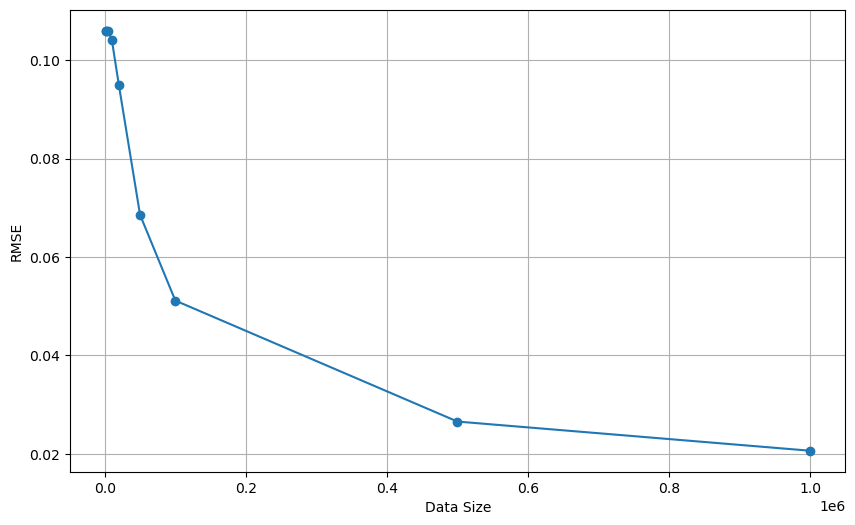

In [28]:
def plot_rmse(sizes, average_rmse_scores):
    """
    Plot the average RMSE scores.

    Args:
        sizes (list): List of sizes for which RMSE was calculated.
        average_rmse_scores (list): Average RMSE scores per size.
        base_dir (str): Base directory for the experiment (used in the title).
    """
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, average_rmse_scores, marker='o')
    plt.xlabel('Data Size')
    plt.ylabel('RMSE')
    plt.grid(True)
    plt.show()

plot_rmse(sizes, average_rmse_vi)

In [3]:
# GIBBS STUFF

import pandas as pd
gibbs = pd.read_csv('coverage.csv')


In [22]:
gibbs.head()

,dataset_ix,N,K,V,ci-90-coverage,RMSE,RMSE_normalized
0,1,1000,5,100,0.8971,0.105738,0.998903
1,2,1000,5,100,0.8960,0.105641,0.997990
2,3,1000,5,100,0.8977,0.105749,0.999011
3,4,1000,5,100,0.8961,0.105775,0.999256
4,5,1000,5,100,0.8975,0.105675,0.998308


In [25]:

gibbs_rmse = []
for VK, df in gibbs.groupby(['V','K']):
    print(VK)
    print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        gibbs_rmse = df.groupby('N')['RMSE'].apply(np.mean)
        



(100, 5)
N
1000      10
2000      10
5000      10
10000     10
20000     10
50000     10
100000    10
500000     1
Name: count, dtype: int64
hey
(200, 10)
N
1000       9
2000       9
5000       9
10000      9
20000      9
50000      9
100000     9
500000     1
1000000    1
Name: count, dtype: int64


In [3]:
# GIBBS STUFF

import pandas as pd
import numpy as np
gibbs = pd.read_csv('coverage-gooby.csv')


gibbs_rmse = []
for VK, df in gibbs.groupby(['V','K']):
    print(VK)
    print(df['N'].value_counts())
    if VK == (100, 5):
        print('hey')
        gibbs_rmse = df.groupby('N')['RMSE'].apply(np.mean)
        



(100, 10)
N
500000     10
2000000    10
1000000    10
Name: count, dtype: int64
(200, 5)
N
50000      10
500000     10
5000       10
2000000    10
10000      10
1000000    10
100000     10
20000      10
2000       10
1000       10
Name: count, dtype: int64


[1000, 2000, 5000, 10000, 20000, 50000, 100000, 500000]

In [3]:

def plot_comparison_rmse(sizes, average_rmse_vi, average_rmse_hmc, gibbs_rmse=[]):
    """
    Plot the average RMSE scores for VI and HMC on a log-log scale.

    Args:
        sizes (list): List of sizes for which RMSE was calculated.
        average_rmse_vi (list): Average RMSE scores for VI.
        average_rmse_hmc (list): Average RMSE scores for HMC.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, average_rmse_vi, marker='o', label='MFVI', color='tab:orange', linewidth=2)
    plt.plot(sizes, average_rmse_hmc, marker='o', label='HMC', color='tab:blue', linewidth=2)
    if len(gibbs_rmse):
        rmse = np.array([None for i in sizes])
        rmse[0:len(gibbs_rmse)] = gibbs_rmse
        plt.plot(sizes, rmse, marker='o', label='Gibbs', color='tab:green', linewidth=2,  linestyle='--')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Data Size', fontsize=14)
    plt.ylabel('RMSE', fontsize=14)
    #plt.title('Comparison of RMSE for VI and HMC', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)
    plt.yticks(fontsize=13)
    plt.xticks(fontsize=13)
    plt.show()

plot_comparison_rmse(sizes, average_rmse_vi, average_rmse_hmc, gibbs_rmse.values)

NameError: name 'sizes' is not defined

2

In [5]:
1+1

2

/tmp/ipykernel_1739606/1324072829.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('summer', lut=len(gibbs.groupby(['V', 'K']))+1)


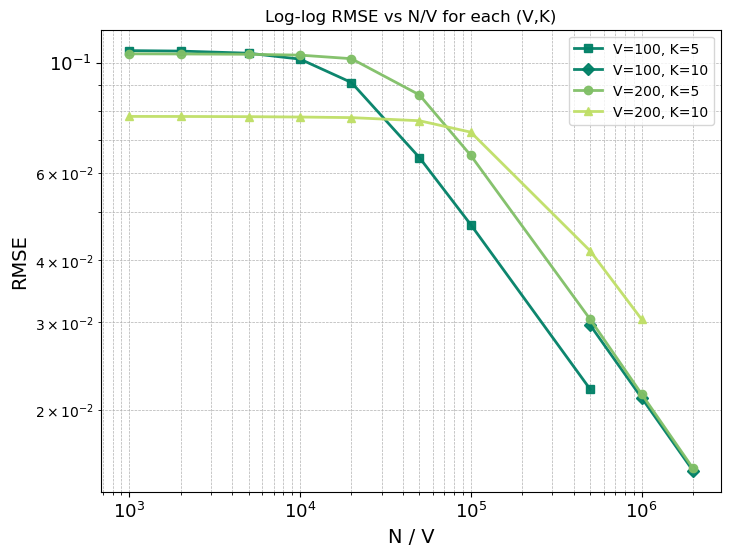

In [ ]:
# per size
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

dolan = pd.read_csv('coverage-dolan.csv')
gooby = pd.read_csv('coverage-gooby.csv')

gibbs = pd.concat([dolan, gooby])

plt.figure(figsize=(8, 6))

cmap = cm.get_cmap('summer', lut=len(gibbs.groupby(['V', 'K']))+1)
markers = [ 's', 'D','o', '^', 'v', 'P']
for idx,((V, K), df) in enumerate(gibbs.groupby(['V', 'K'])):
    # Compute N/V
    #x_values = df['N'] / V
    
    # Compute mean RMSE for each N
    gibbs_rmse = df.groupby('N')['RMSE'].mean()
    if (V,K)==(200,10):
        dff = df
    x_vals = list(gibbs_rmse.index)

    color = cmap((idx-0.3)/ len(gibbs.groupby(['V', 'K'])))
    marker = markers[idx % len(markers)] 
    # Plot log-log
    plt.loglog(x_vals, gibbs_rmse,  linestyle='-', label=f'V={V}, K={K}', color=color, alpha=0.95,linewidth=2.0, marker=marker)

# Labels and legend
plt.xlabel('N / V', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.legend()
#plt.title('Log-log RMSE vs N/V for each (V,K)')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.show()

/tmp/ipykernel_1739606/3268369251.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('summer', lut=len(gibbs.groupby(['V', 'K']))+1)


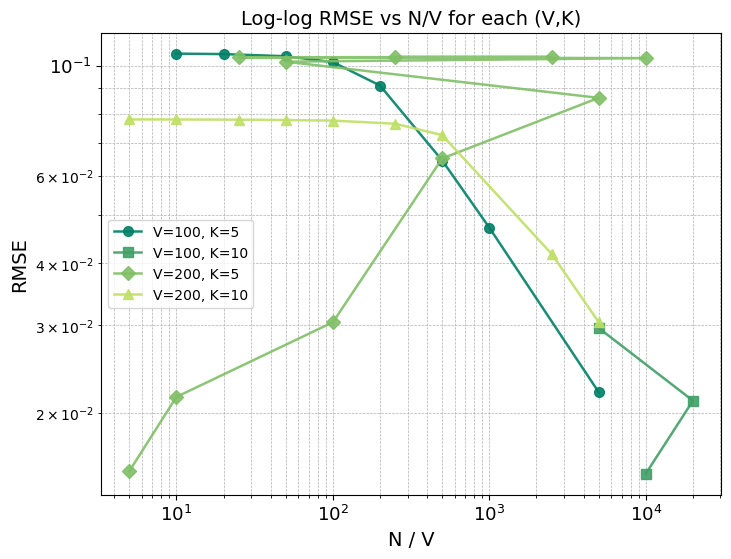

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load data
dolan = pd.read_csv('coverage-dolan.csv')
gooby = pd.read_csv('coverage-gooby.csv')

# Combine datasets
gibbs = pd.concat([dolan, gooby])

# Define plot
plt.figure(figsize=(8, 6))

# Define a colormap and distinct markers
cmap = cm.get_cmap('summer', lut=len(gibbs.groupby(['V', 'K']))+1)
markers = ['o', 's', 'D', '^', 'v', 'P']  # Max 6 unique markers

# Iterate through (V, K) groups
for idx, ((V, K), df) in enumerate(gibbs.groupby(['V', 'K'])):
    # Compute N/V
    x_values = df['N'] / V  # x-axis: N/V
    
    # Compute mean RMSE for each N
    gibbs_rmse = df.groupby('N')['RMSE'].mean()
    x_vals = x_values.unique()  # Ensure x-axis matches grouped values

    # Select color and marker
    color = cmap(idx / len(gibbs.groupby(['V', 'K'])))
    marker = markers[idx % len(markers)]  # Cycle through markers
    
    # Plot log-log
    plt.loglog(x_vals, gibbs_rmse, marker=marker, linestyle='-', 
               label=f'V={V}, K={K}', color=color, alpha=0.9, linewidth=1.8, markersize=7)

# Labels and legend
plt.xlabel('N / V', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.legend(fontsize=10, loc='best', frameon=True)
plt.title('Log-log RMSE vs N/V for each (V,K)', fontsize=14)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)

# Show plot
plt.show()
